<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_HW_2_1_%D0%90%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA_%D0%B4%D0%BB%D1%8F_%D0%BF%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B8_%D0%BB%D1%96%D0%BD%D1%96%D0%B8%CC%86%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
medical_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/Модулі/Модуль 2 Лінійна регресія/Модуль 2. Лінійна регресія - Дата/Medical Charges.csv")

In [ ]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16 884.92
1,18,male,33.77,1,no,southeast,1 725.55
2,28,male,33.00,3,no,southeast,4 449.46
3,33,male,22.70,0,no,northwest,21 984.47
4,32,male,28.88,0,no,northwest,3 866.86


**Висновки**

1. Провести EDA з розбором кожної колонки - які там дані бувають, чи є викиди, яке середнє / медіана, який розподіл даних, чи є аномалії в розподілах
2. Вивести корреляції між стовпцями і проагалізувати їх
3. Кожному стовпцю необхідно дати якийсь коефіцієнт, наскільки він впливає на Target (charges). Як ці коефіцієнти порахувати ще не знаю. Можливо, чим більша кореляція - тим вищий коефіцієнт

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [ ]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

**Висновки**

Дані між чоловіками і жвнками розподілені приблизно однаково. Єдине, що при рівні charges від 0 до 2000 менше жінок, але інші біни розподілені однаково.
Чоловіки міють вищий Q3, на рівні 19 000, коли жінки мають Q3 на рівні 14 000. це говорить про те, що чоловіки більше платять за страхування і стать буде впливати на наш Target

In [ ]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

**Висновки**

Дані по регіонам теж розподілені приблино однаково. Найнижчі оплати мають люди з регіону 'Southwest', а найбільші - з регіону 'Southeast'

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [ ]:
px.histogram(medical_df, x='region', color='smoker', title='Region vs Smoker')
#px.histogram(medical_df, x='region', color='smoker',  barnorm='percent', title='Region vs Smoker')

**Висновки**

Вивела додатково ще дані нормалізованими, щоб зручніше було розуміти чи є відмінності в розподілі курців по регіонах

Курців в регіоні 'Southeast' більше (25%), ніж в інших регіонах (17-20%). Можливо це і є причина, чому там більше charges

In [ ]:
medical_df.children.value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [ ]:
px.histogram(medical_df, x='children', color='smoker', title='Children vs Smoker')
#px.histogram(medical_df, x='children', color='smoker',  barnorm='percent',  title='Children vs Smoker')

**Висновки**

З розподілу в кількості курців і некурців в залежності від кількості дітей, різниці між групами не видно

Проте, якщо побудувати нормалізований розподіл, то видно, що в групі, де 3 дитини, курців трхохи більше (25%), а в групі де 5 дітей - менше ніж в інших групах (всього 5%). Але в групі з 5 дітьми всього 18 людей, з яких тільки 1 курець.  Тому я б не дуже звертала увагу на цю группу людей

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [48]:
px.violin(medical_df, x='charges', color='children', title='charges vs children', category_orders={'children': sorted(medical_df['children'].unique())})

In [47]:
fig = px.scatter(medical_df,
                 x='charges',
                 y='children',
                 title='Сhildren vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

**Висновки**

Людей з 4 та 5 дітьми доволі мало. Тому ці групи для аналізу не дуже показові.
У всіх інших групах суми charges розподілені приблизно однаково - найбільше між 1500 і 12 000;

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [49]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [50]:
def estimate_charges(age, w, b):
    return w * age + b

In [51]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

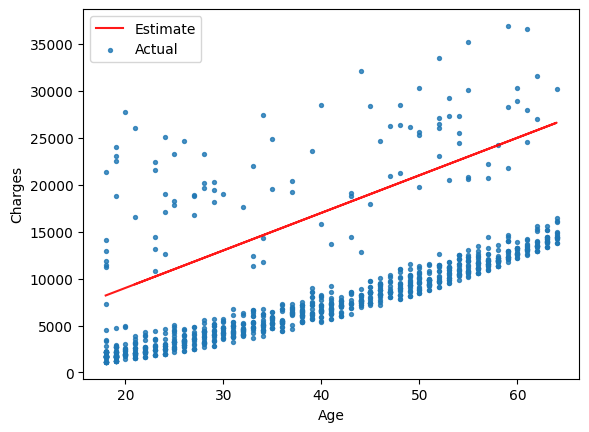

In [53]:
try_parameters(non_smoker_df, 400, 1000)

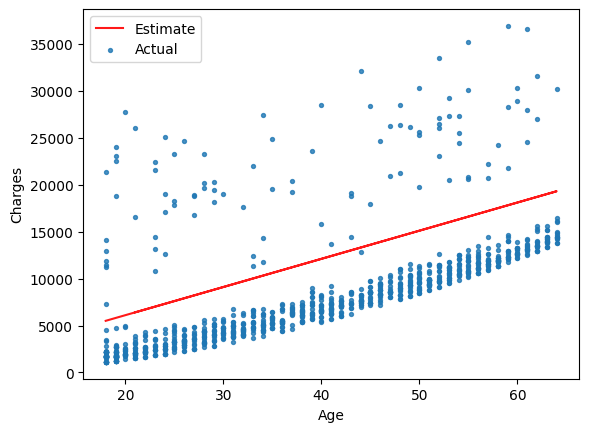

In [54]:
try_parameters(non_smoker_df, 300, 100)

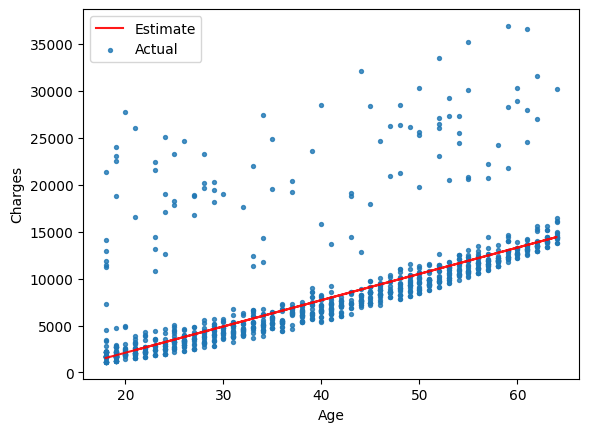

In [69]:
try_parameters(non_smoker_df, 280, -3500)

**Висновки**
1. По моделям, побудованим на лекції (400, 5000), було видно, що лінія схожа по нахилу, але знаходиться зависоко. Щоб її опустити, необхідно зменшии b. В першому варіанті я спробувала зменшити до 1000. Проте лінія все одно була дуже високо. Також звевнула увагу, що лінія трохи дужче дивиться вверх, ніж потрібно.Необхідно трохи зменшити значення w
2. В другому варіанті я зменшила w до 300 і b до 100. Лінія по куту нахилу вже була схожа на потрібну, але все ще зависоко
3. В третьому варіанті я ще трошечки зменшила w до 280, а b - аж до -3500, щоб лінія була в потрібному місці.

Тепер лінія схожа на потрібну.

Аутлаерів в цю модель не враховуємо, скільки більшість данних лежить внизу. Можливо, на них впливають інші параметри

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [73]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  9718.601840724683


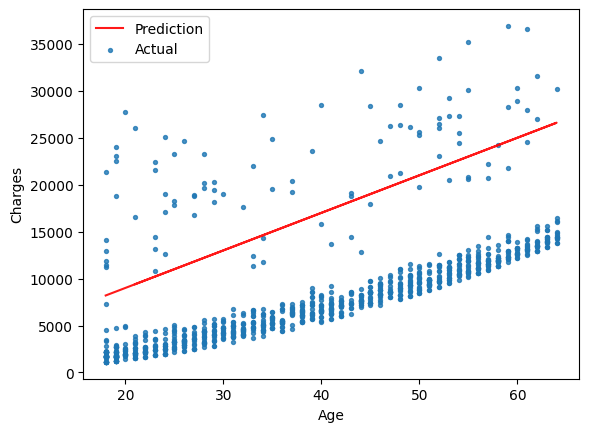

In [74]:
try_parameters( 400, 1000)

RMSE Loss:  5837.053173265296


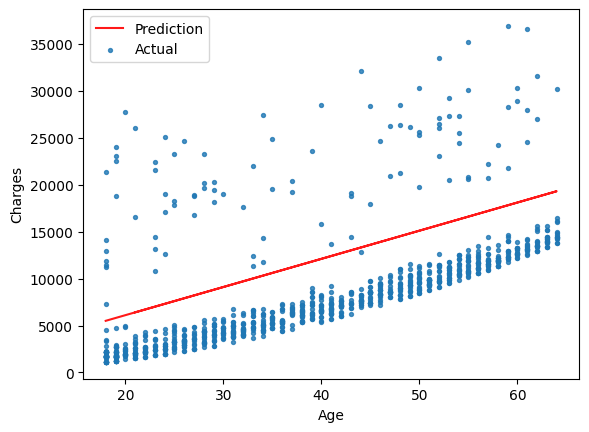

In [75]:
try_parameters( 300, 100)

RMSE Loss:  4753.176967946348


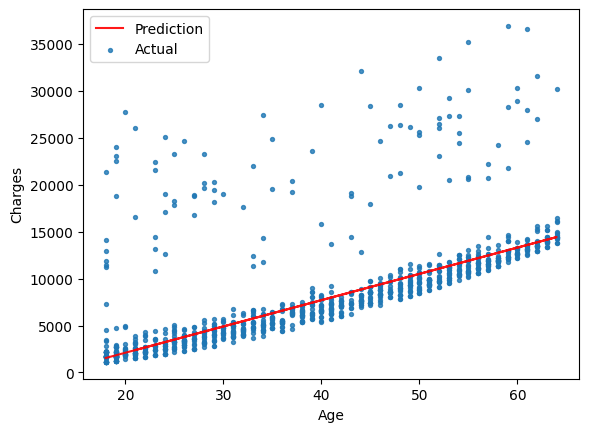

In [76]:
try_parameters(280, -3500)

**Висновки**

Хоч візуально лінія і лежить на нижніх точках, RMSE все одно дуже великий - 4753$. Скорін за все це через аутлайнерів